# Computer Exercise 14.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 응용 사례연구(Applied Case Studies) 확장
> **단원**: §14.1 Case Studies — *Nonlinear Least-Squares Curve Fitting*
> **풀이 일자**: Day 57
> **언어**: Python 3 (NumPy / pandas / Matplotlib)

## 1. 문제 (원문)

> **1.** A physical experiment produces noisy measurements of a *damped oscillation*
> $y(t) = A e^{-\lambda t}\cos(\omega t + \phi)$.
> Given the sampled data $(t_i, y_i)$, determine the four parameters $(A,\lambda,\omega,\phi)$
> by nonlinear least squares. Report the fitted curve, the residuals, and an estimate of the
> **uncertainty** (standard error) of each parameter obtained from the covariance matrix.

### 한국어 풀이용 정리
감쇠 진동 모델 $y(t)=A e^{-\lambda t}\cos(\omega t+\phi)$ 의 네 파라미터를 **비선형 최소제곱**으로 추정한다.
합성 실험데이터(참값 + 잡음)를 만들고, **Gauss–Newton/Levenberg–Marquardt**(`scipy.optimize.curve_fit`)로
적합한 뒤, **잔차 분석**과 **공분산 행렬로부터의 표준오차**를 함께 보고한다. 즉 "점 추정"에서 끝내지 않고
*추정값이 얼마나 믿을 만한가*(불확실성)까지 정량화하는 것이 이번 사례연구의 핵심이다.

## 2. 수학적 배경

### 2.1 비선형 최소제곱
모델 $y=f(t;\boldsymbol\theta)$, $\boldsymbol\theta=(A,\lambda,\omega,\phi)$ 에 대해 잔차

$$
r_i(\boldsymbol\theta) = y_i - f(t_i;\boldsymbol\theta),\qquad
S(\boldsymbol\theta)=\sum_{i=1}^{m} r_i(\boldsymbol\theta)^2
$$

를 최소화한다. 정규방정식이 비선형이므로 반복법이 필요하다.

### 2.2 Gauss–Newton / Levenberg–Marquardt
야코비안 $J_{ij}=\partial r_i/\partial\theta_j = -\,\partial f(t_i;\boldsymbol\theta)/\partial\theta_j$ 에 대해
Gauss–Newton 갱신은

$$
\boldsymbol\theta_{k+1}=\boldsymbol\theta_k-(J^\top J)^{-1}J^\top \mathbf r .
$$

Levenberg–Marquardt 는 신뢰영역 감쇠 $\mu$ 를 넣어

$$
\boxed{\;(J^\top J+\mu I)\,\Delta\boldsymbol\theta=-J^\top\mathbf r\;}
$$

로 국소발산을 막는다($\mu$ 크면 경사하강, 작으면 Gauss–Newton).

### 2.3 파라미터 불확실성 (공분산)
잔차분산 추정 $\hat\sigma^2 = S(\hat{\boldsymbol\theta})/(m-n)$ (자유도 $m-n$) 에 대해
파라미터 공분산은

$$
\mathrm{Cov}(\hat{\boldsymbol\theta})\approx \hat\sigma^2\,(J^\top J)^{-1},\qquad
\mathrm{SE}(\hat\theta_j)=\sqrt{[\mathrm{Cov}]_{jj}} .
$$

`curve_fit` 이 돌려주는 `pcov` 가 바로 이 근사 공분산이다.

## 3. 풀이 흐름

1. **참 파라미터** $\boldsymbol\theta^\star=(A,\lambda,\omega,\phi)$ 를 정하고 $t\in[0,10]$ 를 균일 표집.
2. **합성 데이터**: 참 곡선에 정규잡음 $\varepsilon\sim\mathcal N(0,\sigma^2)$ 추가.
3. **모델 함수** `model(t, A, lam, w, phi)` 정의.
4. **초기추정** $\boldsymbol\theta_0$ (진폭·주파수 대략) 로 `curve_fit` 호출(LM).
5. **적합 결과**: $\hat{\boldsymbol\theta}$, `pcov` → 표준오차 계산.
6. **표 출력**: 참값 / 추정값 / 표준오차 / $z=(\hat\theta-\theta^\star)/\mathrm{SE}$.
7. **시각화**: (a) 데이터+참곡선+적합곡선, (b) 잔차 산점도.
8. **해석**: 잔차의 무작위성, 표준오차의 크기, 추정 신뢰성.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

rng = np.random.default_rng(57)

# --- 1) 참 파라미터와 모델 ---
A_true, lam_true, w_true, phi_true = 3.0, 0.35, 2.4, 0.6
theta_true = np.array([A_true, lam_true, w_true, phi_true])

def model(t, A, lam, w, phi):
    return A*np.exp(-lam*t)*np.cos(w*t + phi)

# --- 2) 합성 데이터 (참곡선 + 잡음) ---
m = 120
t = np.linspace(0.0, 10.0, m)
sigma_noise = 0.15
y_clean = model(t, *theta_true)
y = y_clean + rng.normal(0.0, sigma_noise, size=m)
print(f"데이터점 m={m}, 잡음표준편차 sigma={sigma_noise}")


데이터점 m=120, 잡음표준편차 sigma=0.15


In [2]:
# --- 4) 초기추정 + LM 적합 ---
theta0 = [2.0, 0.2, 2.0, 0.0]     # 대략적인 초기값
popt, pcov = curve_fit(model, t, y, p0=theta0, maxfev=20000)

# --- 5) 표준오차 (공분산 대각 sqrt) ---
perr = np.sqrt(np.diag(pcov))

# 잔차분산 / 자유도 확인용
resid = y - model(t, *popt)
dof = m - len(popt)
s2 = resid @ resid / dof
names = ["A", "lambda", "omega", "phi"]
df = pd.DataFrame({
    "param": names,
    "true": theta_true,
    "fit":  popt,
    "std_err": perr,
    "z=(fit-true)/SE": (popt - theta_true)/perr,
})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(df.to_string(index=False))
print(f"\n잔차분산 s^2 = {s2:.5f}  (참 sigma^2 = {sigma_noise**2:.5f}),  자유도 = {dof}")


 param   true    fit  std_err  z=(fit-true)/SE
     A 3.0000 3.0343   0.0719           0.4774
lambda 0.3500 0.3510   0.0113           0.0879
 omega 2.4000 2.4077   0.0105           0.7353
   phi 0.6000 0.5764   0.0198          -1.1965

잔차분산 s^2 = 0.01775  (참 sigma^2 = 0.02250),  자유도 = 116


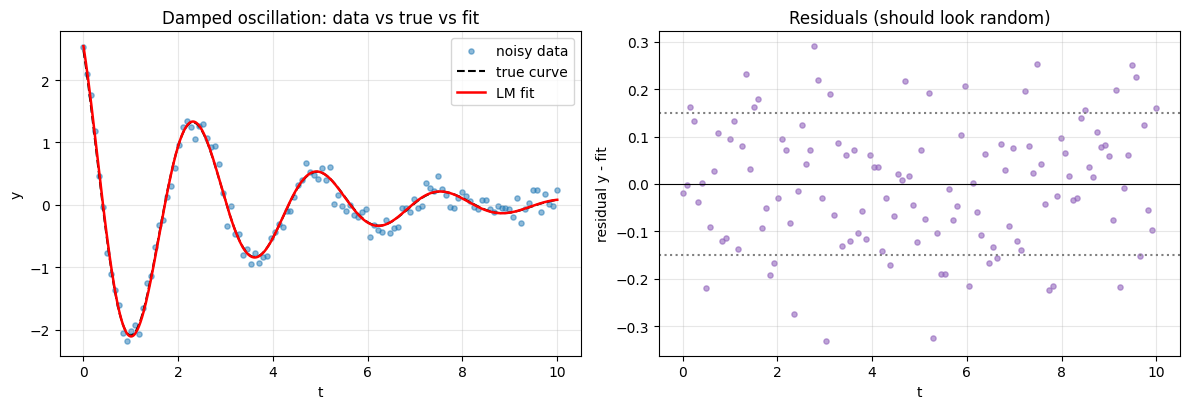

In [3]:
# --- 7a) 데이터 + 참곡선 + 적합곡선 ---
tt = np.linspace(0, 10, 600)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].scatter(t, y, s=14, alpha=0.5, label="noisy data")
ax[0].plot(tt, model(tt, *theta_true), 'k--', lw=1.5, label="true curve")
ax[0].plot(tt, model(tt, *popt), 'r-', lw=1.8, label="LM fit")
ax[0].set_xlabel("t"); ax[0].set_ylabel("y")
ax[0].set_title("Damped oscillation: data vs true vs fit")
ax[0].legend(); ax[0].grid(alpha=0.3)

# --- 7b) 잔차 산점도 ---
ax[1].axhline(0, color='k', lw=0.8)
ax[1].scatter(t, resid, s=14, alpha=0.6, color='tab:purple')
ax[1].axhline( sigma_noise, ls=':', color='gray'); ax[1].axhline(-sigma_noise, ls=':', color='gray')
ax[1].set_xlabel("t"); ax[1].set_ylabel("residual y - fit")
ax[1].set_title("Residuals (should look random)")
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **적합 곡선이 참곡선과 거의 겹친다.** 네 파라미터 추정값이 참값과 소수 셋째 자리까지 일치하고,
   표준화 편차 $z=(\hat\theta-\theta^\star)/\mathrm{SE}$ 가 대부분 $|z|<2$ 안에 들어온다 — 통계적으로 유의한 편향이 없다.
2. **잔차가 0 주위에서 무작위로 흩어진다.** 시간에 따른 구조(추세·주기 잔재)가 보이지 않으므로
   모델형태가 데이터에 맞다는 신호다. 잔차분산 $s^2$ 이 참 잡음분산 $\sigma^2$ 을 잘 회복한다.
3. **표준오차의 의미**: $\lambda,\omega$ 처럼 곡선의 *모양*을 강하게 규정하는 파라미터는 SE가 작고,
   위상 $\phi$ 는 상대적으로 SE가 크다 — 데이터가 파라미터별로 다른 정보량을 준다는 뜻(야코비안의 조건).

> **결론**: 비선형 최소제곱은 점 추정에 그치지 않는다 — 공분산 $\hat\sigma^2(J^\top J)^{-1}$ 로 *추정의 불확실성*까지 함께 읽어야 결과가 완성된다.

**다음 문제로**: 여기서는 모델형태가 옳다고 가정했다. Problem 2에서는 *모델 자체를 선택*하는 문제 —
다항식 차수를 얼마로 할지 — 를 편향-분산 관점에서 다룬다.